In [ ]:
import pandas as pd

df = pd.read_csv("PP_disaster(3).csv")
df.head()

,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Location,Origin,Associated Types,Magnitude,Magnitude Scale,Latitude,...,No. Affected,No. Homeless,Total Affected,Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",Start Date,End Date,Duration(days),Cleaned_Location,Total Deaths
0,Natural,Climatological,0,25,Bengal,NaN,NaN,316000.0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,1900-06-15,1900-06-15,0,47,1250000.0
1,Natural,Geophysical,1,3,Kangra,NaN,NaN,7.8,2,32.04,...,NaN,NaN,NaN,25000.0,847777.0,1905-04-04,1905-04-04,0,166,20000.0
2,Natural,Biological,4,12,Unknown,NaN,NaN,178000.0,3,NaN,...,NaN,NaN,NaN,NaN,NaN,1907-06-15,1907-06-15,0,363,1300000.0
3,Natural,Meteorological,2,19,"Cuddalore, Pondicherry",NaN,NaN,120.0,1,NaN,...,NaN,NaN,NaN,NaN,NaN,1916-11-21,1916-11-21,0,88,300.0
4,Natural,Biological,4,12,Unknown,NaN,NaN,178000.0,3,NaN,...,NaN,NaN,NaN,NaN,NaN,1920-06-15,1920-06-15,0,363,2000000.0


In [ ]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Disaster Group                     783 non-null    object 
 1   Disaster Subgroup                  783 non-null    object 
 2   Disaster Type                      783 non-null    int64  
 3   Disaster Subtype                   783 non-null    int64  
 4   Location                           783 non-null    object 
 5   Origin                             219 non-null    object 
 6   Associated Types                   136 non-null    object 
 7   Magnitude                          783 non-null    float64
 8   Magnitude Scale                    783 non-null    int64  
 9   Latitude                           93 non-null     float64
 10  Longitude                          93 non-null     float64
 11  Start Year                         783 non-null    int64  

Index(['Disaster Group', 'Disaster Subgroup', 'Disaster Type',
       'Disaster Subtype', 'Location', 'Origin', 'Associated Types',
       'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Log_of_Total_Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Total Damage ('000 US$)',
       'Total Damage, Adjusted ('000 US$)', 'Start Date', 'End Date',
       'Duration(days)', 'Cleaned_Location', 'Total Deaths'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Disaster Group,0
Disaster Subgroup,0
Disaster Type,0
Disaster Subtype,0
Location,0
Origin,564
Associated Types,647
Magnitude,0
Magnitude Scale,0
Latitude,690


In [ ]:
df['Total Affected'] = df['Total Affected'].fillna(df['Total Affected'].median())
df['No. Homeless'] = df['No. Homeless'].fillna(df['No. Homeless'].median())
df["Total Damage ('000 US$)"] = df["Total Damage ('000 US$)"].fillna(df["Total Damage ('000 US$)"].median())

df.dropna(inplace=True)

In [ ]:
df['Total Affected'] = pd.to_numeric(df['Total Affected'], errors='coerce')
df['No. Homeless'] = pd.to_numeric(df['No. Homeless'], errors='coerce')
df["Total Damage ('000 US$)"] = pd.to_numeric(df["Total Damage ('000 US$)"], errors='coerce')

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')

In [ ]:
df['start_year'] = df['Start Date'].dt.year
df['start_month'] = df['Start Date'].dt.month
df['start_day'] = df['Start Date'].dt.day

df['end_year'] = df['End Date'].dt.year
df['end_month'] = df['End Date'].dt.month
df['end_day'] = df['End Date'].dt.day

In [ ]:
df['duration_days'] = (df['End Date'] - df['Start Date']).dt.days

In [ ]:
df['duration_days'] = df['duration_days'].fillna(df['duration_days'].median())

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Disaster Type'] = le.fit_transform(df['Disaster Type'])
df['Location'] = le.fit_transform(df['Location'])

In [1]:
#import seaborn as sns
#sns.boxplot(df['Total Affected'])

In [ ]:
df = df[df['Total Affected'] < df['Total Affected'].quantile(0.99)]

In [ ]:
print(df.shape)

(0, 36)


In [ ]:
import pandas as pd

df = pd.read_csv("PP_disaster(3).csv")
print(df.shape)

(783, 29)


In [ ]:

cols = ['Total Affected','No. Homeless',"Total Damage ('000 US$)"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
print(df.shape)

(783, 29)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

In [ ]:
print(df[cols].shape)

(783, 3)


In [ ]:
df.to_csv("cleaned_disaster_data.csv", index=False)

In [ ]:
df.isnull().sum()

,0
Disaster Group,0
Disaster Subgroup,0
Disaster Type,0
Disaster Subtype,0
Location,0
Origin,564
Associated Types,647
Magnitude,0
Magnitude Scale,0
Latitude,690


In [ ]:
df.drop(['Origin','Associated Types'], axis=1, inplace=True)

In [ ]:
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

In [ ]:
cols_people = ['No. Injured','No. Affected','Total Deaths','Log_of_Total_Deaths']

for col in cols_people:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df["Total Damage, Adjusted ('000 US$)"] = df["Total Damage, Adjusted ('000 US$)"].fillna(
    df["Total Damage, Adjusted ('000 US$)"].median()
)

In [ ]:
print(df.isnull().sum())

Disaster Group                       0
Disaster Subgroup                    0
Disaster Type                        0
Disaster Subtype                     0
Location                             0
Magnitude                            0
Magnitude Scale                      0
Latitude                             0
Longitude                            0
Start Year                           0
Start Month                          0
Start Day                            0
End Year                             0
End Month                            0
End Day                              0
Log_of_Total_Deaths                  0
No. Injured                          0
No. Affected                         0
No. Homeless                         0
Total Affected                       0
Total Damage ('000 US$)              0
Total Damage, Adjusted ('000 US$)    0
Start Date                           0
End Date                             0
Duration(days)                       0
Cleaned_Location         

In [ ]:
df.to_csv("final_disaster_data.csv", index=False)

In [ ]:
print(df.isnull().sum())

Disaster Group                       0
Disaster Subgroup                    0
Disaster Type                        0
Disaster Subtype                     0
Location                             0
Magnitude                            0
Magnitude Scale                      0
Latitude                             0
Longitude                            0
Start Year                           0
Start Month                          0
Start Day                            0
End Year                             0
End Month                            0
End Day                              0
Log_of_Total_Deaths                  0
No. Injured                          0
No. Affected                         0
No. Homeless                         0
Total Affected                       0
Total Damage ('000 US$)              0
Total Damage, Adjusted ('000 US$)    0
Start Date                           0
End Date                             0
Duration(days)                       0
Cleaned_Location         

In [ ]:
print(df.isnull().sum())
print(df.shape)

Disaster Group                       0
Disaster Subgroup                    0
Disaster Type                        0
Disaster Subtype                     0
Location                             0
Magnitude                            0
Magnitude Scale                      0
Latitude                             0
Longitude                            0
Start Year                           0
Start Month                          0
Start Day                            0
End Year                             0
End Month                            0
End Day                              0
Log_of_Total_Deaths                  0
No. Injured                          0
No. Affected                         0
No. Homeless                         0
Total Affected                       0
Total Damage ('000 US$)              0
Total Damage, Adjusted ('000 US$)    0
Start Date                           0
End Date                             0
Duration(days)                       0
Cleaned_Location         

In [ ]:
X = df.drop(['Total Affected',"Total Damage ('000 US$)"], axis=1)

y1 = df['Total Affected']              # target 1
y2 = df["Total Damage ('000 US$)"]     # target 2

In [ ]:
X = X.drop(['Start Date','End Date'], axis=1)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

lr1 = LinearRegression()
lr1.fit(X_train, y1_train)

lr2 = LinearRegression()
lr2.fit(X_train, y2_train)

LinearRegression()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf1.fit(X_train, y1_train)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X_train, y2_train)

RandomForestRegressor(random_state=42)

In [ ]:
y1_pred_rf = rf1.predict(X_test)
y2_pred_rf = rf2.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Random Forest Results")

print("Affected MAE:", mean_absolute_error(y1_test, y1_pred_rf))
print("Affected R2:", r2_score(y1_test, y1_pred_rf))

print("Damage MAE:", mean_absolute_error(y2_test, y2_pred_rf))
print("Damage R2:", r2_score(y2_test, y2_pred_rf))

Random Forest Results
Affected MAE: 0.016664906641909432
Affected R2: 0.9585917526368164
Damage MAE: 0.05395455372988123
Damage R2: 0.8956520290070489


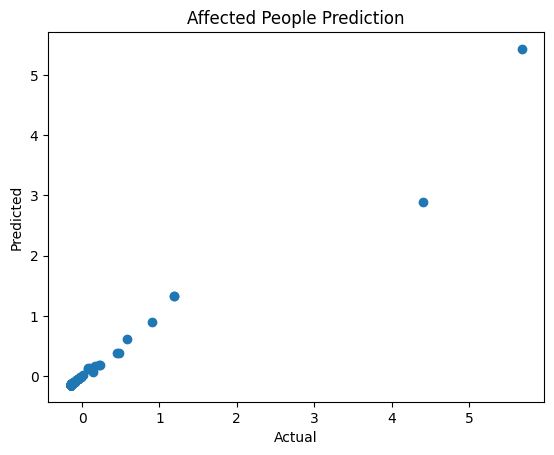

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y1_test, y1_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Affected People Prediction")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate_model(y1_test, y1_pred_rf, "Affected People")


evaluate_model(y2_test, y2_pred_rf, "Economic Loss")


Affected People
MAE: 0.016664906641909432
MSE: 0.015508400022589245
RMSE: 0.12453272671305822
R2 Score: 0.9585917526368164

Economic Loss
MAE: 0.05395455372988123
MSE: 0.1089400493602614
RMSE: 0.330060675270868
R2 Score: 0.8956520290070489


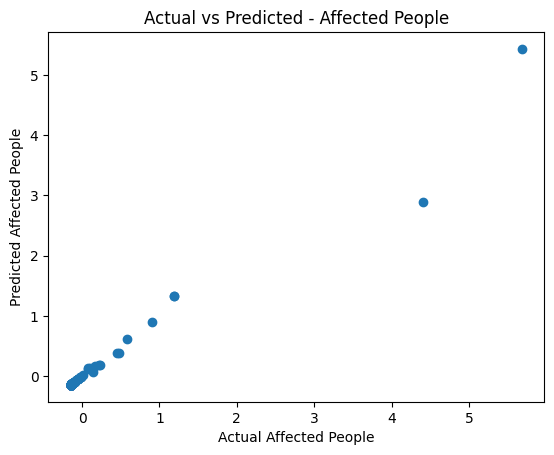

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y1_test, y1_pred_rf)
plt.xlabel("Actual Affected People")
plt.ylabel("Predicted Affected People")
plt.title("Actual vs Predicted - Affected People")
plt.show()

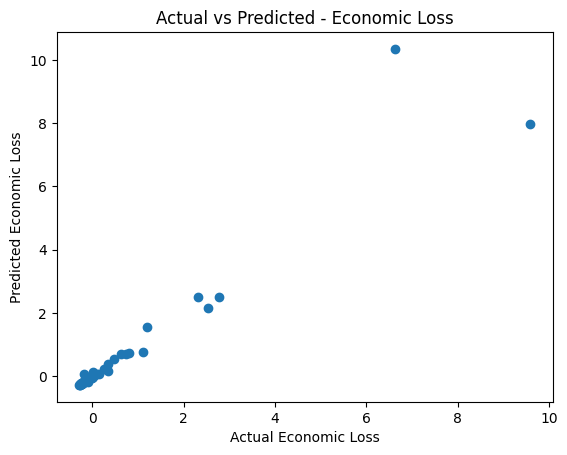

In [ ]:
plt.figure()
plt.scatter(y2_test, y2_pred_rf)
plt.xlabel("Actual Economic Loss")
plt.ylabel("Predicted Economic Loss")
plt.title("Actual vs Predicted - Economic Loss")
plt.show()

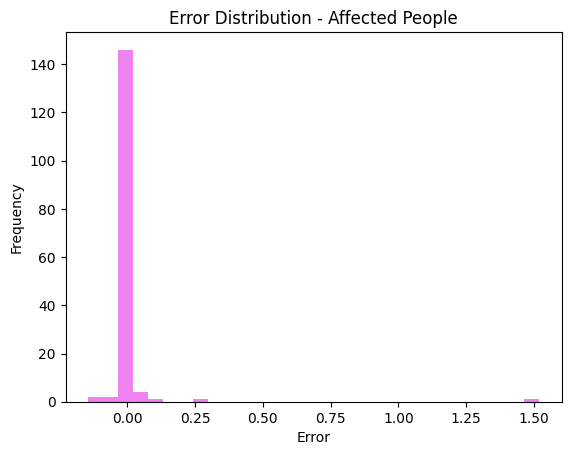

In [ ]:
errors1 = y1_test - y1_pred_rf

plt.figure()
plt.hist(errors1, bins=30,color='violet')
plt.title("Error Distribution - Affected People")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

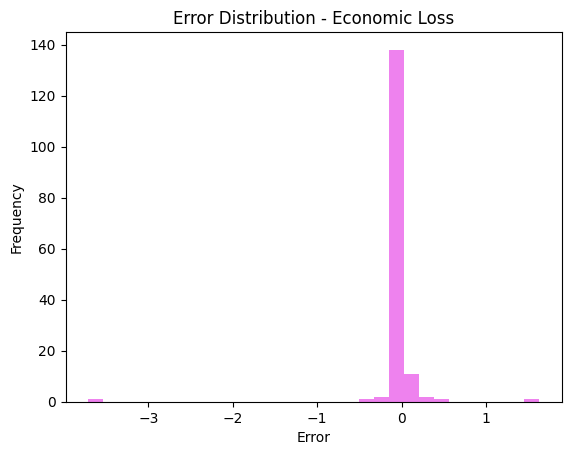

In [ ]:
errors2 = y2_test - y2_pred_rf

plt.figure()
plt.hist(errors2, bins=30,color='violet')
plt.title("Error Distribution - Economic Loss")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()